In [94]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
import geopandas as gpd

from pathlib import Path
from warnings import simplefilter

simplefilter("ignore")  # ignore warnings to clean up output cells

In [95]:
# https://www.kaggle.com/datasets/aradhanahirapara/product-retail-price-survey-2017-2025
df = pd.read_csv("data/Retail_Prices_of_Products.csv")
df.head()

,Year,Month,GEO,Product Category,Products,VALUE,Taxable,Total tax rate,Value after tax,Essential,COORDINATE,UOM
0,2017,January,Province 1,Meat & Poultry,"Beef stewing cuts, per kilogram",12.66,No,11.0,12.66,Essential,11.10,Dollars
1,2017,January,Province 1,Meat & Poultry,"Beef striploin cuts, per kilogram",21.94,No,11.0,21.94,Essential,11.20,Dollars
2,2017,January,Province 1,Meat & Poultry,"Beef top sirloin cuts, per kilogram",13.44,No,11.0,13.44,Essential,11.30,Dollars
3,2017,January,Province 1,Meat & Poultry,"Beef rib cuts, per kilogram",20.17,No,11.0,20.17,Essential,11.41,Dollars
4,2017,January,Province 1,Meat & Poultry,"Ground beef, per kilogram",9.12,No,11.0,9.12,Essential,11.40,Dollars


In [96]:
df['Date'] = df['Month'].astype(str) + ' ' + df['Year'].astype(str)
df['Date'] = pd.to_datetime(df['Date'], format='%B %Y')
df.head()

,Year,Month,GEO,Product Category,Products,VALUE,Taxable,Total tax rate,Value after tax,Essential,COORDINATE,UOM,Date
0,2017,January,Province 1,Meat & Poultry,"Beef stewing cuts, per kilogram",12.66,No,11.0,12.66,Essential,11.10,Dollars,2017-01-01
1,2017,January,Province 1,Meat & Poultry,"Beef striploin cuts, per kilogram",21.94,No,11.0,21.94,Essential,11.20,Dollars,2017-01-01
2,2017,January,Province 1,Meat & Poultry,"Beef top sirloin cuts, per kilogram",13.44,No,11.0,13.44,Essential,11.30,Dollars,2017-01-01
3,2017,January,Province 1,Meat & Poultry,"Beef rib cuts, per kilogram",20.17,No,11.0,20.17,Essential,11.41,Dollars,2017-01-01
4,2017,January,Province 1,Meat & Poultry,"Ground beef, per kilogram",9.12,No,11.0,9.12,Essential,11.40,Dollars,2017-01-01


In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118482 entries, 0 to 118481
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Year              118482 non-null  int64         
 1   Month             118482 non-null  str           
 2   GEO               118482 non-null  str           
 3   Product Category  118482 non-null  str           
 4   Products          118482 non-null  str           
 5   VALUE             118482 non-null  float64       
 6   Taxable           118482 non-null  str           
 7   Total tax rate    118482 non-null  float64       
 8   Value after tax   118482 non-null  float64       
 9   Essential         118482 non-null  str           
 10  COORDINATE        118482 non-null  float64       
 11  UOM               118482 non-null  str           
 12  Date              118482 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(1), str(7)
memory usage: 11.8 

In [98]:
df.isnull().sum()

Year                0
Month               0
GEO                 0
Product Category    0
Products            0
VALUE               0
Taxable             0
Total tax rate      0
Value after tax     0
Essential           0
COORDINATE          0
UOM                 0
Date                0
dtype: int64

In [99]:
df['Taxable'] = df['Taxable'].astype('category')
df['Essential'] = df['Essential'].astype('category')
df['Product Category'] = df['Product Category'].astype('category')
df['GEO'] = df['GEO'].astype('category')
df = df.dropna(subset=['VALUE'])
df['Price_Level'] = pd.qcut(df['VALUE'], q=3, labels=['Low', 'Medium', 'High'])
df['Month_num'] = df['Date'].dt.month
df['Year_num'] = df['Date'].dt.year

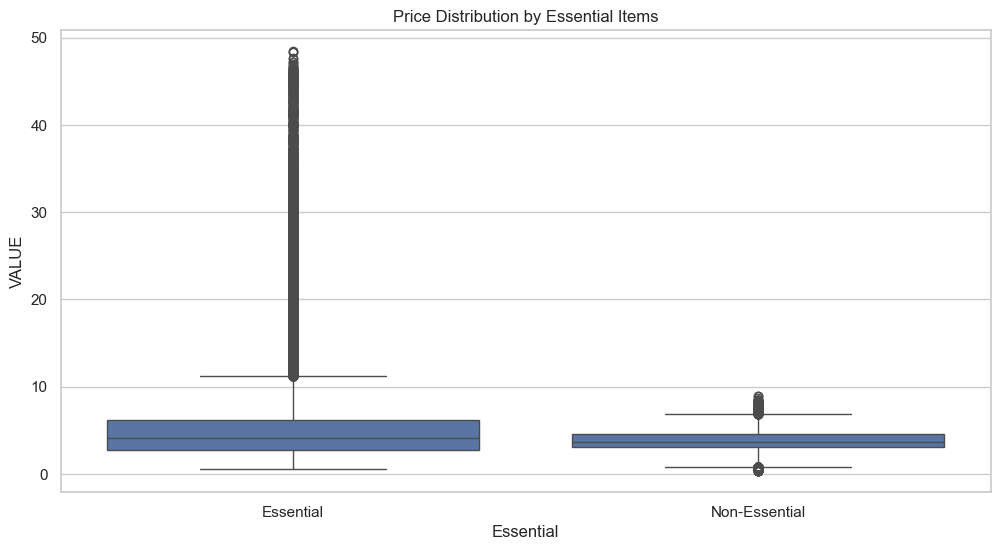

In [100]:
sns.set(style="whitegrid")
plt.figure(figsize=(12,6))
sns.boxplot(x='Essential', y='VALUE', data=df)
plt.title('Price Distribution by Essential Items')
plt.show()

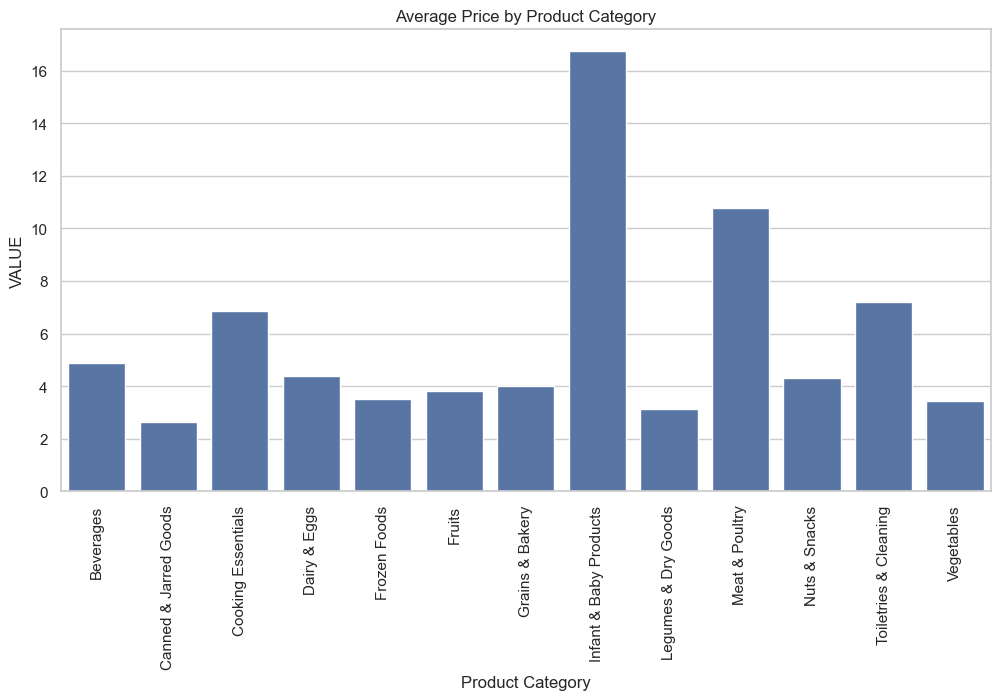

In [101]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Product Category', y='VALUE', ci=None)
plt.xticks(rotation=90)
plt.title('Average Price by Product Category')
plt.show()

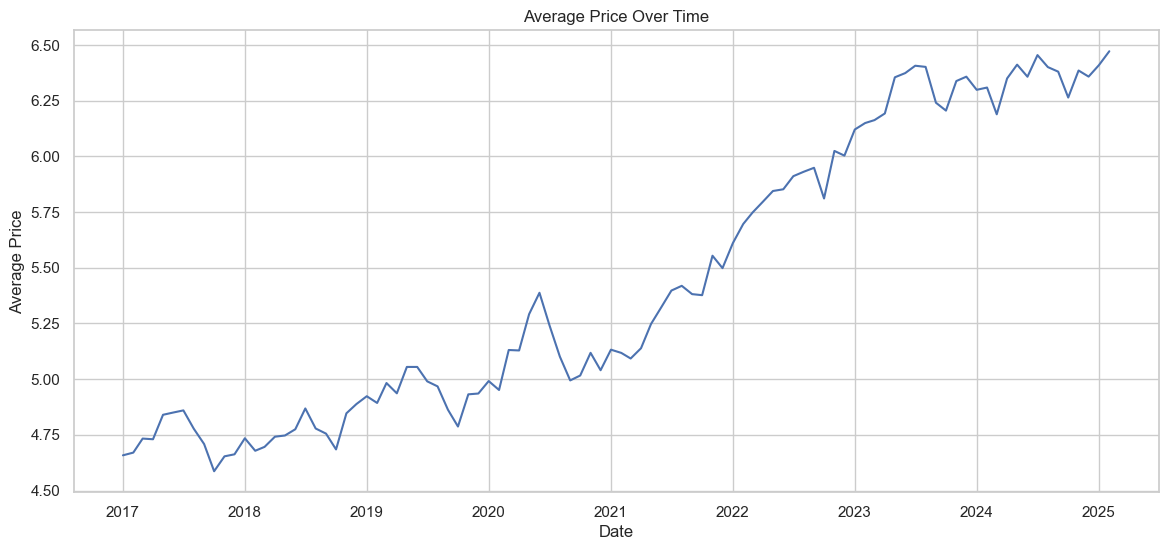

In [102]:
avg_monthly = df.groupby('Date')['VALUE'].mean().reset_index()
plt.figure(figsize=(14,6))
sns.lineplot(data=avg_monthly, x='Date', y='VALUE')
plt.title('Average Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.show()

In [103]:
# linear regression model
reg_data = df[['VALUE', 'Taxable', 'Essential', 'Product Category', 'GEO', 'Month_num', 'Year_num']].copy()
reg_data = pd.get_dummies(reg_data, drop_first=True)
X_reg = reg_data.drop(columns=['VALUE'])
y_reg = reg_data['VALUE']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
# mean_squared_error squared=True replaced by mean_squared_error
# mean_squared_error squared=False replaced by root_mean_squared_error
print("Linear Regression MSE:", mean_squared_error(y_test_r, y_pred_r))
print("Linear Regression RMSE:", root_mean_squared_error(y_test_r, y_pred_r))
print("Linear Regression R2 Score:", r2_score(y_test_r, y_pred_r))
#Linear Regression R2 Score: 0.38819888825565796 is very, we need as close to 1 as posible


Linear Regression MSE: 16.06264635184851
Linear Regression RMSE: 4.007823143783731
Linear Regression R2 Score: 0.38819888825565796


In [104]:
# random forest model
reg_data = df[['VALUE', 'Taxable', 'Essential', 'Product Category', 'GEO', 'Month_num', 'Year_num']].copy()
reg_data = pd.get_dummies(reg_data, drop_first=True)
X_reg = reg_data.drop(columns=['VALUE'])
y_reg = reg_data['VALUE']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestRegressor
reg_model = RandomForestRegressor()
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
# mean_squared_error squared=True replaced by mean_squared_error
# mean_squared_error squared=False replaced by root_mean_squared_error
print("Linear Regression MSE:", mean_squared_error(y_test_r, y_pred_r))
print("Linear Regression RMSE:", root_mean_squared_error(y_test_r, y_pred_r))
print("Linear Regression R2 Score:", r2_score(y_test_r, y_pred_r))
#Linear Regression R2 Score: 0.14354872477867375 is very low, we need as close to 1 as posible


Linear Regression MSE: 22.563705374595678
Linear Regression RMSE: 4.750126879841809
Linear Regression R2 Score: 0.14058370390127017


<Axes: >

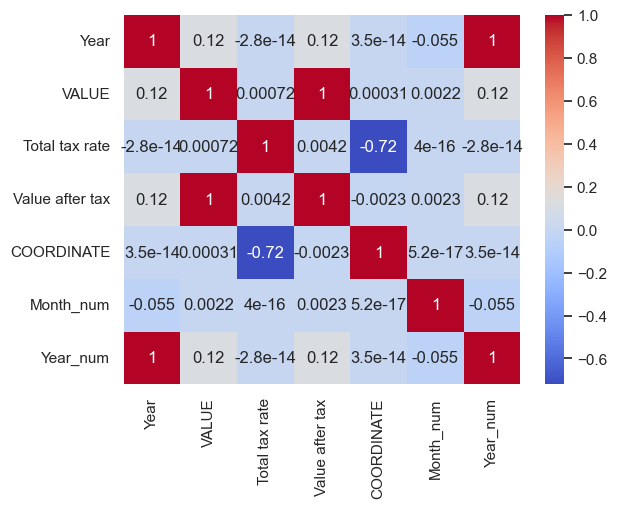

In [105]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [106]:
data = df

In [107]:
for col in data.columns:
    le=LabelEncoder()
    data[col]=le.fit_transform(data[col])
x=data.drop(["VALUE"],axis=1)
x=x.drop(["Value after tax"],axis=1)
y=data["VALUE"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
ss=StandardScaler()
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

In [108]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regression": DecisionTreeRegressor()
}
param_grid = {
    "Linear Regression": {}, 
    "Decision Tree Regression": {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    }
}
def tune_model(model, params, x_train, y_train):
    grid_search = GridSearchCV(model, param_grid=params, cv=5, scoring="r2", n_jobs=-1)
    grid_search.fit(x_train, y_train)
    return grid_search.best_estimator_
best_models = {}
for model_name, model in models.items():
    print(f"Tuning {model_name}...")
    best_models[model_name] = tune_model(model, param_grid[model_name], x_train, y_train)

Tuning Linear Regression...
Tuning Decision Tree Regression...


In [109]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
model_scores = {}
for model_name, model in best_models.items():
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    model_scores[model_name] = r2  # Store R² Score

    print(f"\n📊 {model_name} Performance:")
    print(f"R² Score: {r2*100:.4f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")


📊 Linear Regression Performance:
R² Score: 25.0023
MAE: 291.1395
RMSE: 429.4542

📊 Decision Tree Regression Performance:
R² Score: 98.7860
MAE: 22.9539
RMSE: 54.6400


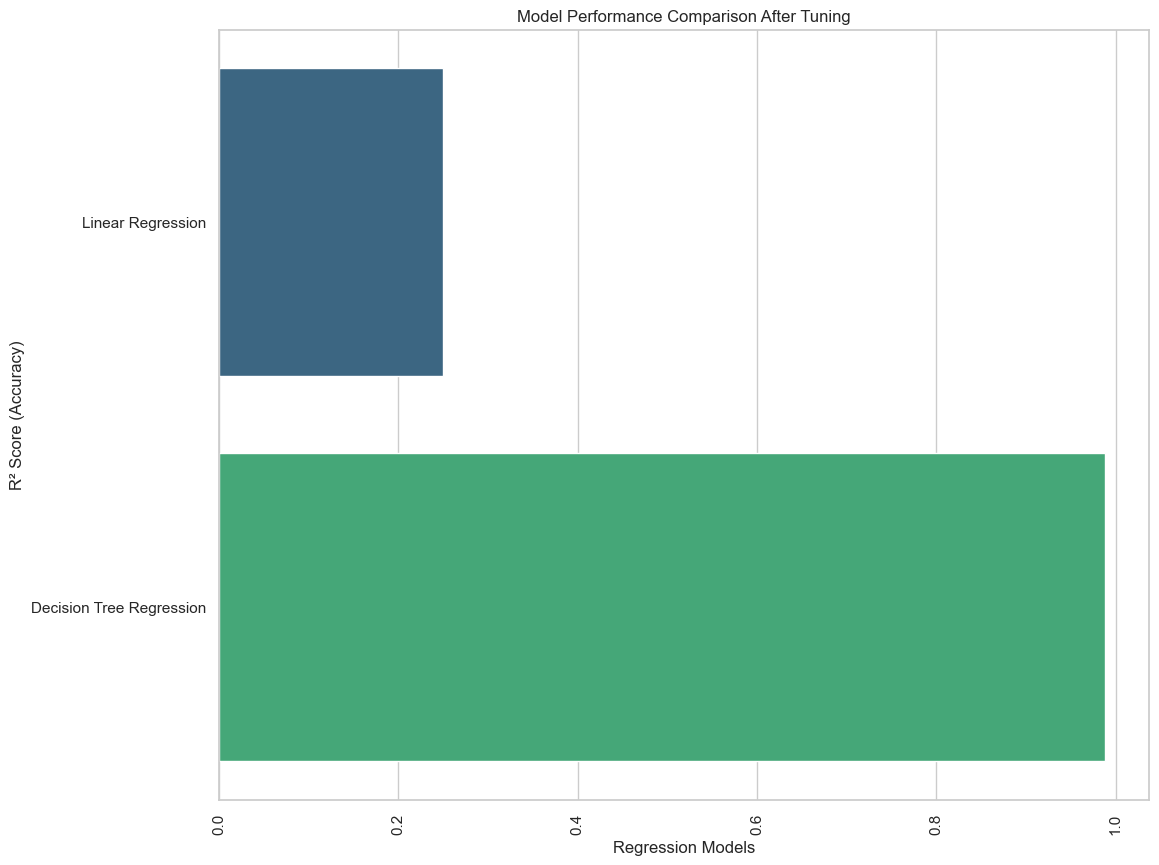

In [110]:
scores_df = pd.DataFrame(list(model_scores.items()), columns=["Model", "R² Score"])
plt.figure(figsize=(12, 10))
sns.barplot(y="Model", x="R² Score", data=scores_df, palette="viridis")
plt.xlabel("Regression Models")
plt.ylabel("R² Score (Accuracy)")
plt.title("Model Performance Comparison After Tuning")
plt.xticks(rotation=90)
plt.show()

In [111]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data['VALUE'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -52.23389532485332
p-value: 0.0


ADF Statistic: -52.23389532485332 which is very low indicates strong evidence against the null hypothesis of non-stationarity

p-value: 0.0 is far below the typical significance level (e.g., 0.05), meaning we reject the null hypothesis of non-stationarity

The series is stationary, we do not need to difference the series further. We can proceed with fitting the ARIMA model, starting with d=0 (no differencing)

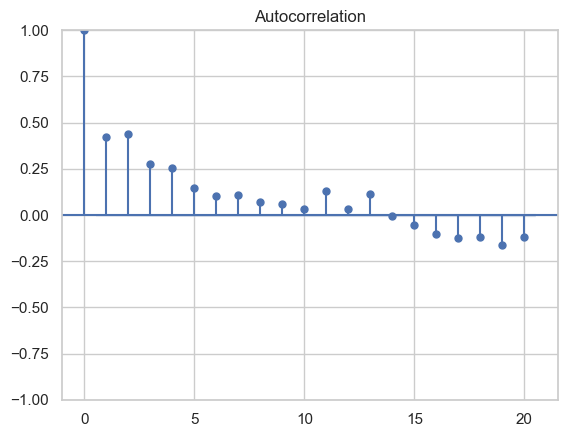

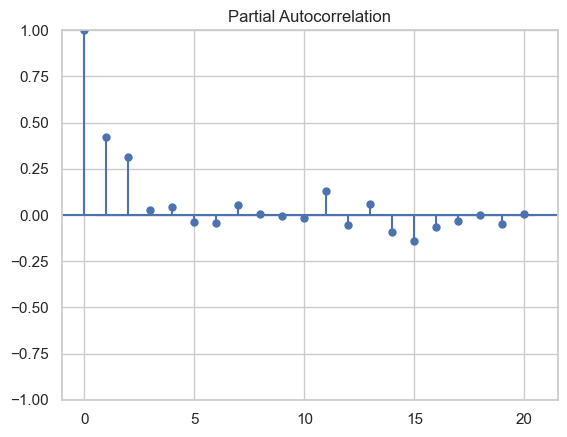

In [112]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
data = df
plot_acf(data['VALUE'], lags=20)  # Autocorrelation plot
plot_pacf(data['VALUE'], lags=20)  # Partial autocorrelation plot
plt.show()

In [113]:
# Based on ACF/PACF, determine p and q 

# ARIMA Model fitting
p = 1  # Autoregressive order (p)
d = 0  # Differencing order (d) as series is stationary
q = 1  # Moving average order (q)

# Fit the ARIMA model
model = ARIMA(data['VALUE'], order=(p, d, q))
model_fit = model.fit()
# Model Summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  VALUE   No. Observations:               118482
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -887801.747
Date:                Fri, 28 Aug 2026   AIC                        1775611.494
Time:                        11:13:36   BIC                        1775650.224
Sample:                             0   HQIC                       1775623.159
                             - 118482                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        507.2911      6.724     75.446      0.000     494.113     520.470
ar.L1          0.8195      0.003    260.190      0.000       0.813       0.826
ma.L1         -0.4933      0.004   -121.242      0.0

In [114]:
# Predict the next 10 periods
n_forecast = 10
forecast = model_fit.forecast(steps=n_forecast)

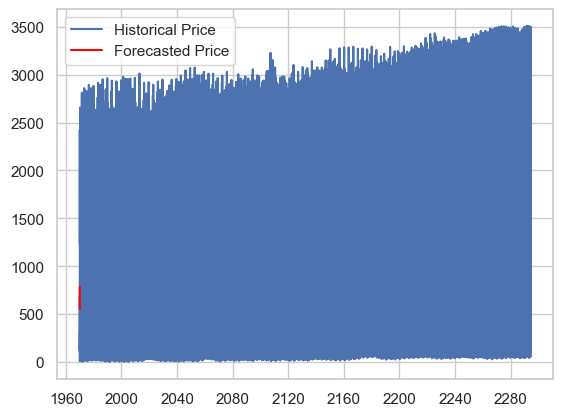

In [115]:
# Plot the forecasted values
plt.plot(data.index, data['VALUE'], label='Historical Price')
forecast_index = pd.date_range(start=data.index[-1], periods=n_forecast+1, freq='D')[1:]
plt.plot(forecast_index, forecast, label='Forecasted Price', color='red')

plt.legend()
plt.show()

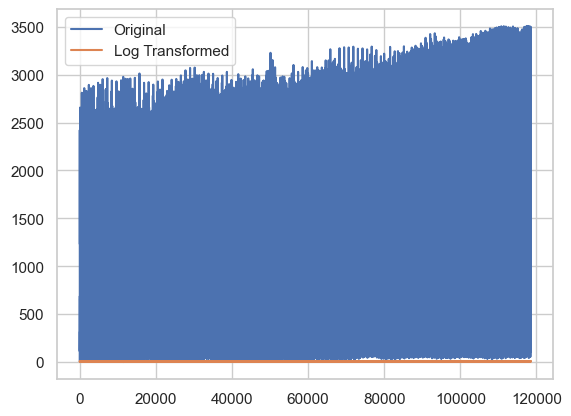

In [116]:
import numpy as np

# Apply log transformation (add a small constant to avoid log(0))
data['VALUE_log'] = np.log(data['VALUE'] + 1)

# Plot the transformed data to check the effect
plt.plot(data['VALUE'], label='Original')
plt.plot(data['VALUE_log'], label='Log Transformed')
plt.legend()
plt.show()

In [117]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data['VALUE_log'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
if result[1] < 0.05:
    print("Log-transformed data is stationary.")
else:
    print("Log-transformed data is not stationary.")

ADF Statistic: -36.876857812633304
p-value: 0.0
Log-transformed data is stationary.


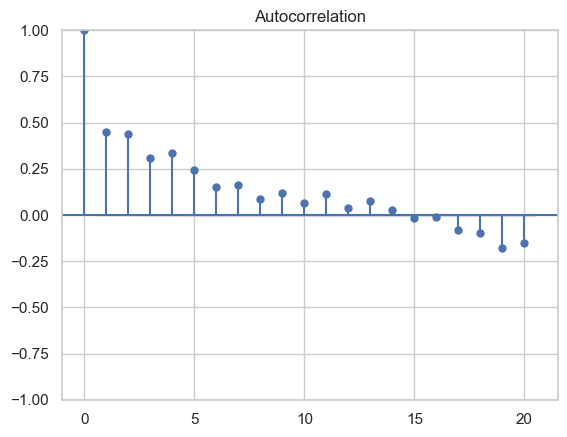

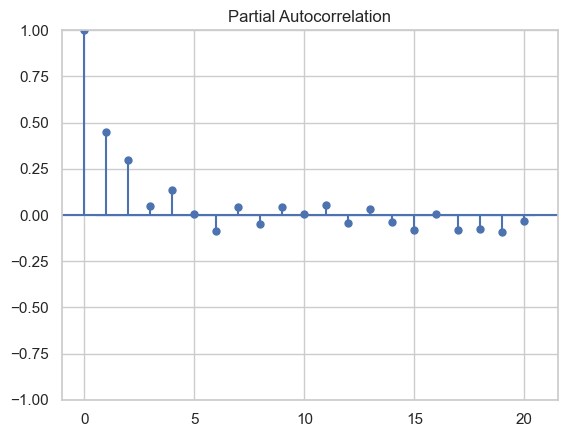

In [118]:
plot_acf(data['VALUE_log'], lags=20)
plot_pacf(data['VALUE_log'], lags=20)
plt.show()

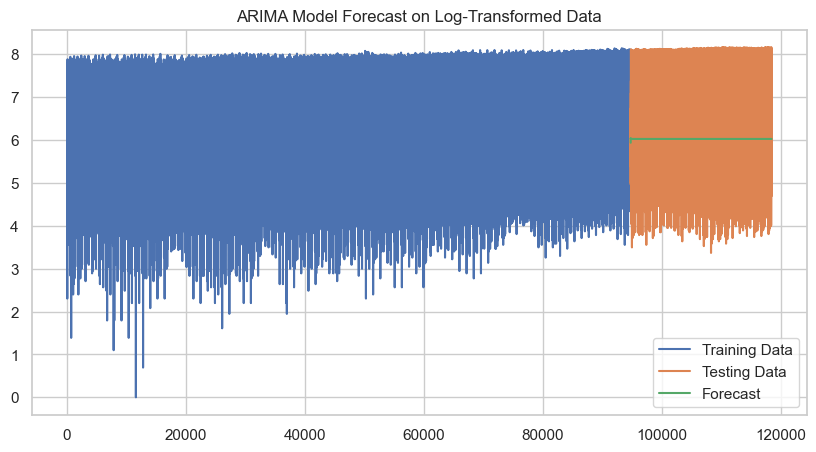

ARIMA model summary:
                               SARIMAX Results                                
Dep. Variable:              VALUE_log   No. Observations:                94785
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -95446.357
Date:                Fri, 28 Aug 2026   AIC                         190904.714
Time:                        11:28:31   BIC                         190961.470
Sample:                             0   HQIC                        190921.979
                              - 94785                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6282      0.002   -282.185      0.000      -0.633      -0.624
ar.L2         -0.3284      0.003   -106.160      0.000      -0.334      -0.322
ar.L3         -0.2723      0.00

In [121]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# we fit ARIMA model again with log transformed
VALUE_log = data['VALUE_log']

# Split data
train_size = int(len(VALUE_log) * 0.8)
train, test = VALUE_log[:train_size], VALUE_log[train_size:]

# Fit ARIMA model
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))
forecast_index = test.index

# Plot the results
plt.figure(figsize=(10,5))
plt.plot(train, label='Training Data')
plt.plot(test, label='Testing Data')
plt.plot(forecast_index, forecast, label='Forecast')
plt.legend(loc='best')
plt.title('ARIMA Model Forecast on Log-Transformed Data')
plt.show()

print("ARIMA model summary:")
print(model_fit.summary())


Mean Absolute Error (MAE): 0.5354426463575164
Mean Squared Error (MSE): 0.5456988301780072
Root Mean Squared Error (RMSE): 0.73871430890298
R-Squared: -0.007234680268745519


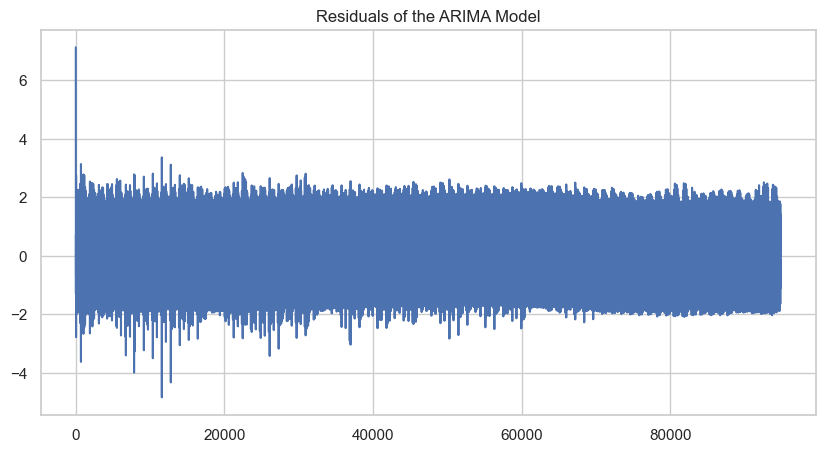

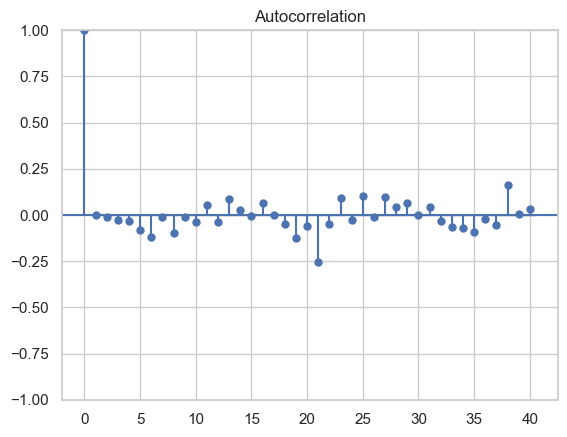

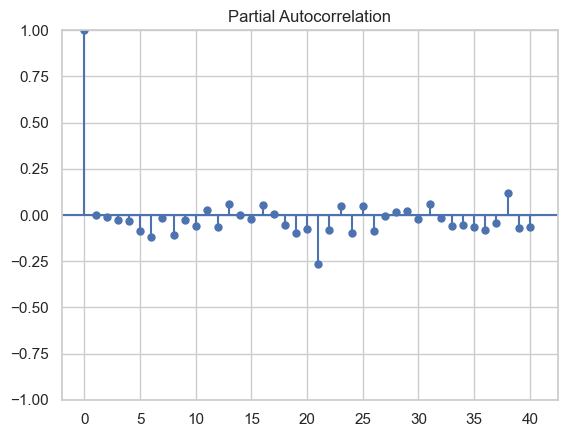

In [122]:
# Calculate performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

forecast_array = np.array(forecast)
mae = mean_absolute_error(test, forecast_array)
mse = mean_squared_error(test, forecast_array)
rmse = np.sqrt(mse)
r2 = r2_score(test, forecast_array)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-Squared: {r2}")

# Optional: Plot residuals
residuals = model_fit.resid
plt.figure(figsize=(10, 5))
plt.plot(residuals)
plt.title('Residuals of the ARIMA Model')
plt.show()

# ACF/PACF of residuals
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(residuals, lags=40)
plt.show()
plot_pacf(residuals, lags=40)
plt.show()


R-squared is -0.007 so the model perfomed worse even than a simple horizontal line that just predicts the average value of the data.

                                     SARIMAX Results                                      
Dep. Variable:                              VALUE   No. Observations:                94785
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood             -706206.489
Date:                            Fri, 28 Aug 2026   AIC                        1412422.978
Time:                                    11:38:18   BIC                        1412470.274
Sample:                                         0   HQIC                       1412437.366
                                          - 94785                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8119      0.004    220.833      0.000       0.805       0.819
ma.L1         -0.4894      0.005   

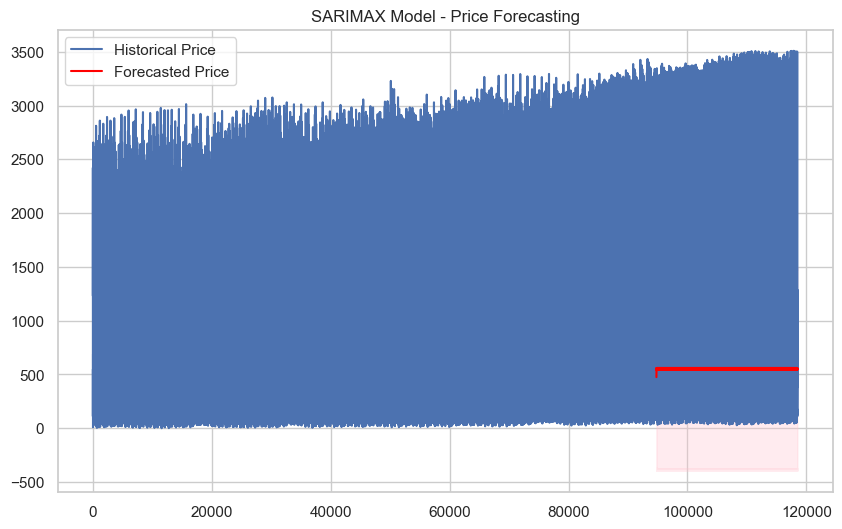

In [ ]:
# build the model using SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Check for missing values
data = df
data = data.dropna(subset=['VALUE'])

train_size = int(len(data) * 0.8)
train, test = data['VALUE'][:train_size], data['VALUE'][train_size:]

# SARIMAX model
model = SARIMAX(train,
                order=(1, 0, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

# Fit the model
model_fit = model.fit(disp=False)

# Print the summary of the model
print(model_fit.summary())

forecast = model_fit.get_forecast(steps=len(test))
# Extract actual forecast values
forecast_array = forecast.predicted_mean.to_numpy()

# Get confidence intervals
conf_int = forecast.conf_int()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['VALUE'], label='Historical Price')
plt.plot(test.index, forecast.predicted_mean, color='red', label='Forecasted Price')
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.legend()
plt.title('SARIMAX Model - Price Forecasting')
plt.show()


Mean Absolute Error (MAE): 336.7657210567343
Mean Squared Error (MSE): 331941.80890513834
Root Mean Squared Error (RMSE): 576.1439133629186
R-Squared: -0.00494939081076029


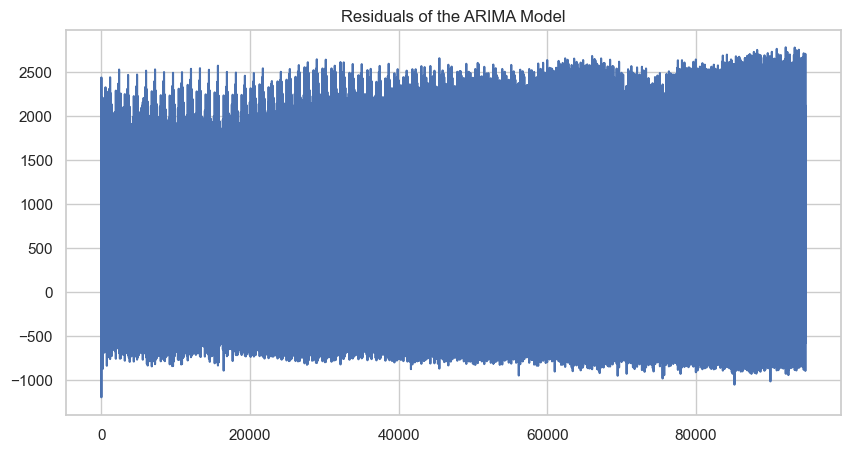

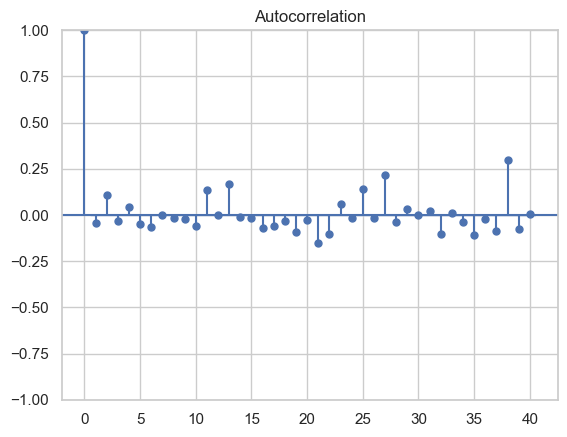

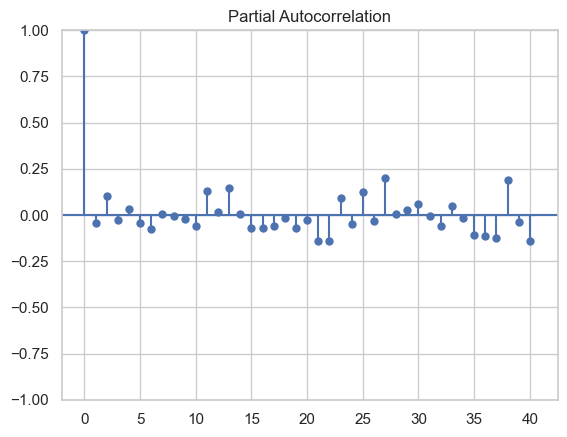

In [128]:
# Calculate performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

forecast_array = forecast.predicted_mean.to_numpy()
mae = mean_absolute_error(test, forecast_array)
mse = mean_squared_error(test, forecast_array)
rmse = np.sqrt(mse)
r2 = r2_score(test, forecast_array)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-Squared: {r2}")

# Optional: Plot residuals
residuals = model_fit.resid
plt.figure(figsize=(10, 5))
plt.plot(residuals)
plt.title('Residuals of the ARIMA Model')
plt.show()

# ACF/PACF of residuals
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(residuals, lags=40)
plt.show()
plot_pacf(residuals, lags=40)
plt.show()


In [134]:
# https://www.kaggle.com/datasets/aradhanahirapara/product-retail-price-survey-2017-2025
df = pd.read_csv("data/Retail_Prices_of_Products.csv")
df=df.drop(["Value after tax", "UOM"],axis=1)
df['Date'] = df['Month'].astype(str) + ' ' + df['Year'].astype(str)
df['Date'] = pd.to_datetime(df['Date'], format='%B %Y')
# Changing Date and Value as required for the Prophet model
df['ds'] = pd.to_datetime(df['Date'], errors='coerce')  # Prophet-compatible date
df['y'] = df['VALUE']  # Target variable
df = df.sort_values(by='Date')
df.head()

,Year,Month,GEO,Product Category,Products,VALUE,Taxable,Total tax rate,Essential,COORDINATE,Date,ds,y
0,2017,January,Province 1,Meat & Poultry,"Beef stewing cuts, per kilogram",12.66,No,11.0,Essential,11.10,2017-01-01,2017-01-01,12.66
809,2017,January,Province 8,Fruits,"Avocado, unit",1.58,No,12.0,Essential,7.29,2017-01-01,2017-01-01,1.58
808,2017,January,Province 8,Fruits,"Strawberries, 454 grams",4.08,No,12.0,Essential,7.84,2017-01-01,2017-01-01,4.08
807,2017,January,Province 8,Fruits,"Cantaloupe, unit",3.35,No,12.0,Essential,7.28,2017-01-01,2017-01-01,3.35
806,2017,January,Province 8,Fruits,"Grapes, per kilogram",7.93,No,12.0,Essential,7.27,2017-01-01,2017-01-01,7.93


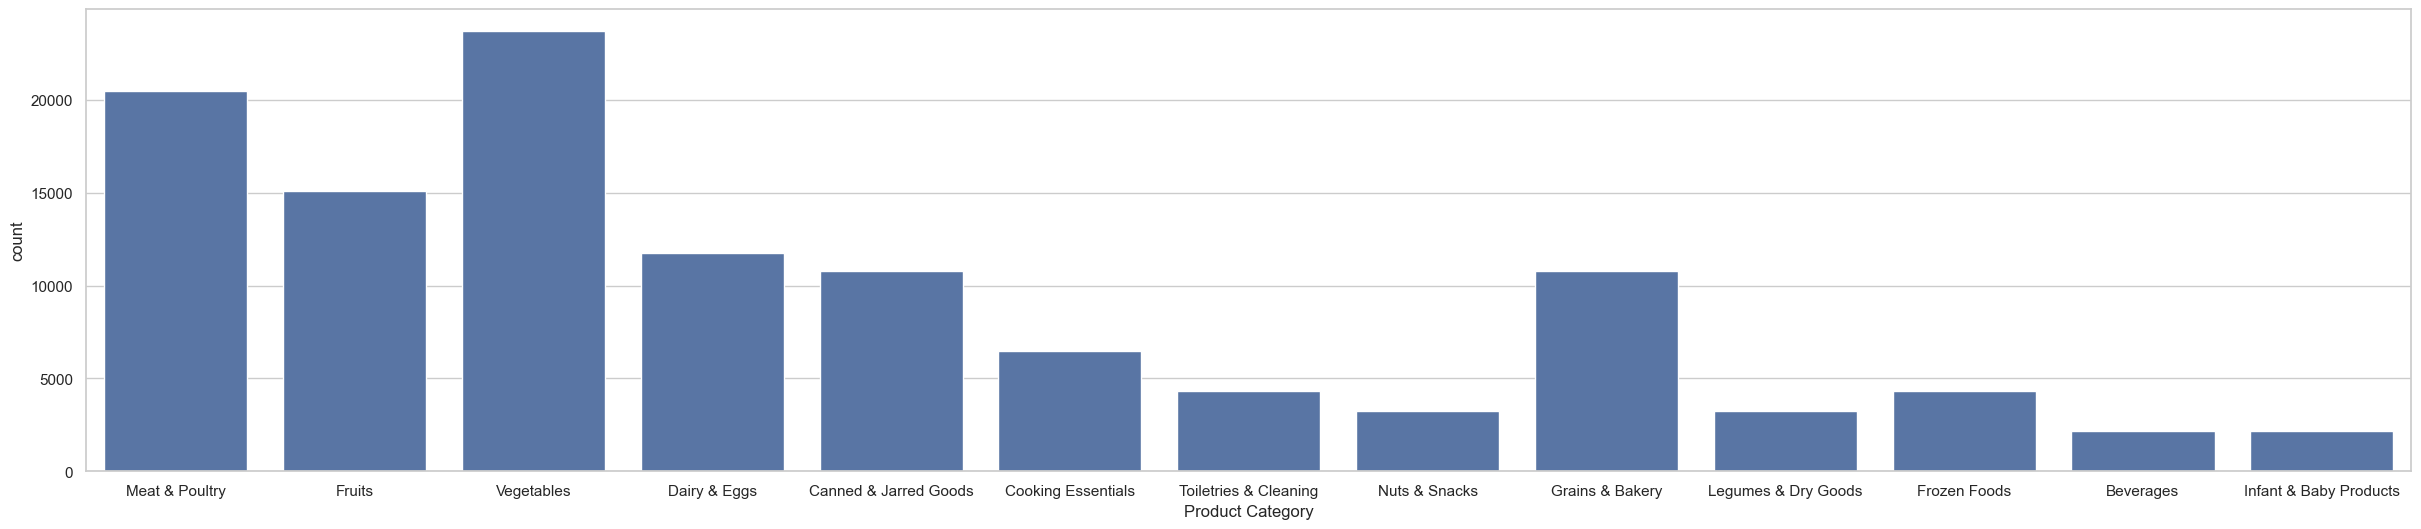

In [136]:
#Bar plots to show frequency of categories
plt.figure(figsize=(30,6))
sns.countplot(x='Product Category', data=df)
plt.show()

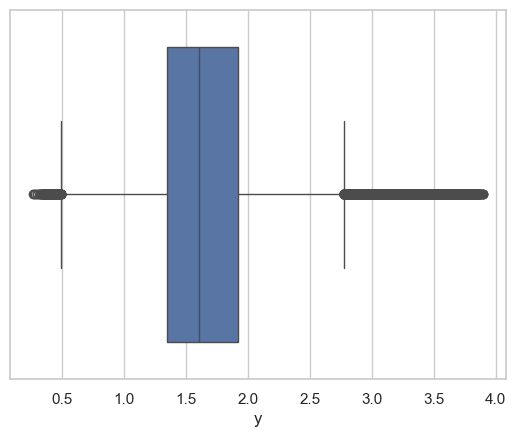

In [137]:
#Apply log transformation
df['y'] = np.log1p(df['y'])

#To find any outliers
sns.boxplot(x=df['y'])
plt.show()

In [138]:
df = df.dropna(subset=['y', 'ds'])  # Remove NaNs
df.head()

,Year,Month,GEO,Product Category,Products,VALUE,Taxable,Total tax rate,Essential,COORDINATE,Date,ds,y
0,2017,January,Province 1,Meat & Poultry,"Beef stewing cuts, per kilogram",12.66,No,11.0,Essential,11.10,2017-01-01,2017-01-01,2.614472
809,2017,January,Province 8,Fruits,"Avocado, unit",1.58,No,12.0,Essential,7.29,2017-01-01,2017-01-01,0.947789
808,2017,January,Province 8,Fruits,"Strawberries, 454 grams",4.08,No,12.0,Essential,7.84,2017-01-01,2017-01-01,1.625311
807,2017,January,Province 8,Fruits,"Cantaloupe, unit",3.35,No,12.0,Essential,7.28,2017-01-01,2017-01-01,1.470176
806,2017,January,Province 8,Fruits,"Grapes, per kilogram",7.93,No,12.0,Essential,7.27,2017-01-01,2017-01-01,2.189416


In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
df_prophet=df[['ds','y']]

#Split data as train and test datasets
train = df_prophet.iloc[:-365]
test = df_prophet.iloc[-365:]

# Create the model
model = Prophet()
# Fit the model
model.fit(train)

# Create a DataFrame with future dates
future = model.make_future_dataframe(periods=365)

# Make predictions
forecast = model.predict(future)

# Extract the predictions corresponding to the test set dates
forecast_test = forecast[-365:]

14:41:10 - cmdstanpy - INFO - Chain [1] start processing
14:41:29 - cmdstanpy - INFO - Chain [1] done processing


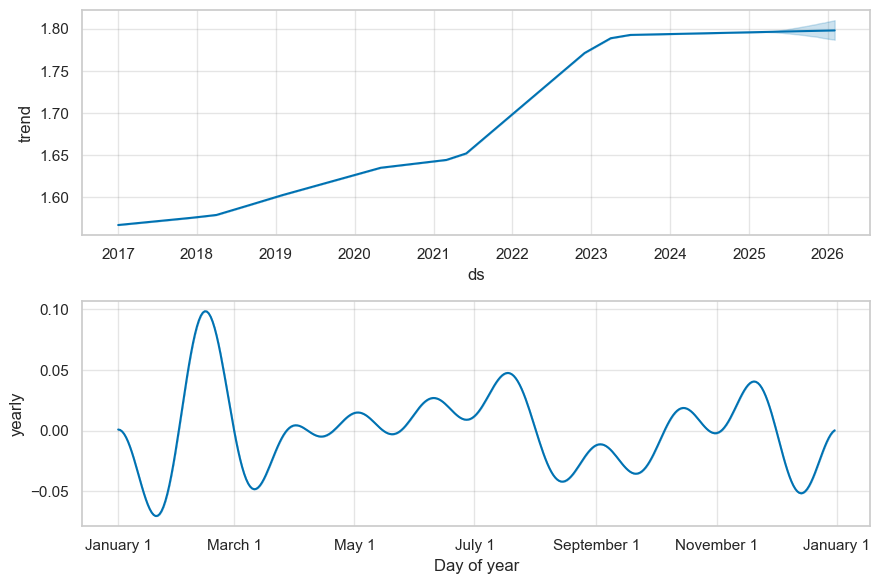

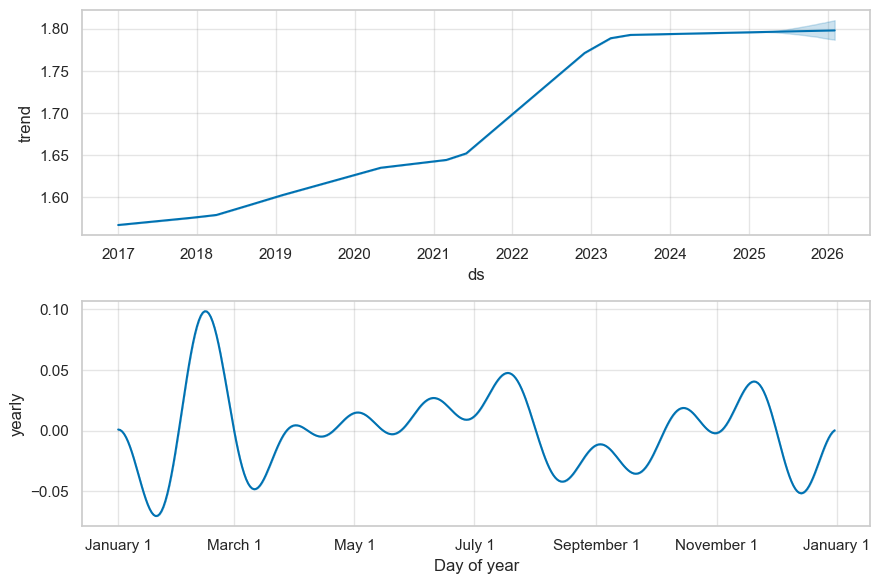

In [140]:
model.plot_components(forecast)


In [141]:
print(forecast.columns)


Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='str')


In [142]:
# Evaluate the model
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(test['y'], forecast_test['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(test['y'], forecast_test['yhat'])

print(f'MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}')


MSE: 0.37, RMSE: 0.61, MAE: 0.44


With MSE: 0.37, RMSE: 0.61, MAE: 0.44, this is actually just an average prediction performance.

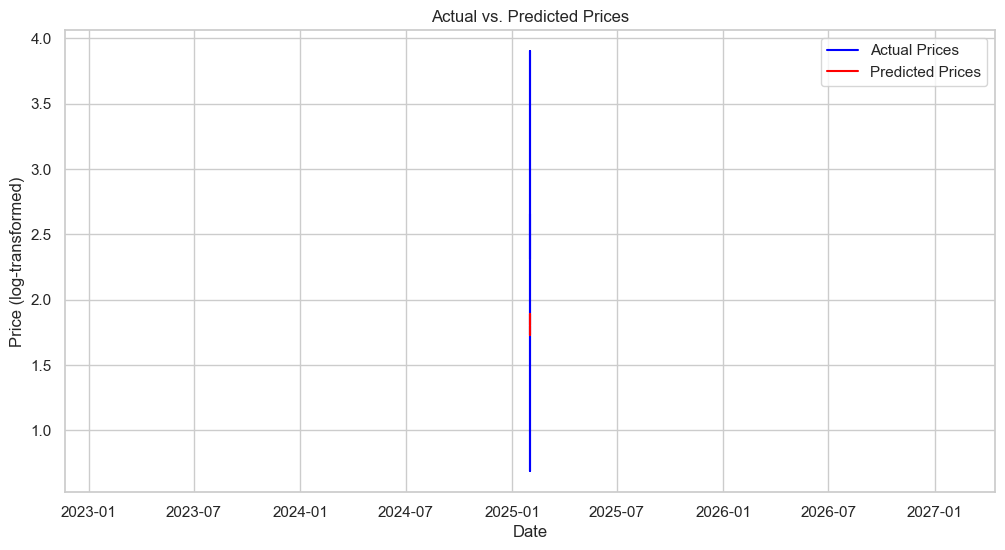

In [143]:
plt.figure(figsize=(12, 6))
plt.plot(test['ds'], test['y'], label="Actual Prices", color='blue')
plt.plot(test['ds'], forecast_test['yhat'], label="Predicted Prices", color='red')
plt.xlabel("Date")
plt.ylabel("Price (log-transformed)")
plt.title("Actual vs. Predicted Prices")
plt.legend()
plt.show()
